# Nigerian Music scraped from Spotify - an analysis

In [136]:
!pip install seaborn


Start where we finished in the last lesson, with data imported and filtered.

In [137]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


df = pd.read_csv("../data/nigerian-songs.csv")
df.head()

,name,album,artist,artist_top_genre,release_date,length,popularity,danceability,acousticness,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature
0,Sparky,Mandy & The Jungle,Cruel Santino,alternative r&b,2019,144000,48,0.666,0.8510,0.420,0.534000,0.1100,-6.699,0.0829,133.015,5
1,shuga rush,EVERYTHING YOU HEARD IS TRUE,Odunsi (The Engine),afropop,2020,89488,30,0.710,0.0822,0.683,0.000169,0.1010,-5.640,0.3600,129.993,3
2,LITT!,LITT!,AYLØ,indie r&b,2018,207758,40,0.836,0.2720,0.564,0.000537,0.1100,-7.127,0.0424,130.005,4
3,Confident / Feeling Cool,Enjoy Your Life,Lady Donli,nigerian pop,2019,175135,14,0.894,0.7980,0.611,0.000187,0.0964,-4.961,0.1130,111.087,4
4,wanted you,rare.,Odunsi (The Engine),afropop,2018,152049,25,0.702,0.1160,0.833,0.910000,0.3480,-6.044,0.0447,105.115,4


We will focus only on 3 genres. Maybe we can get 3 clusters built!

Text(0.5, 1.0, 'Top genres')

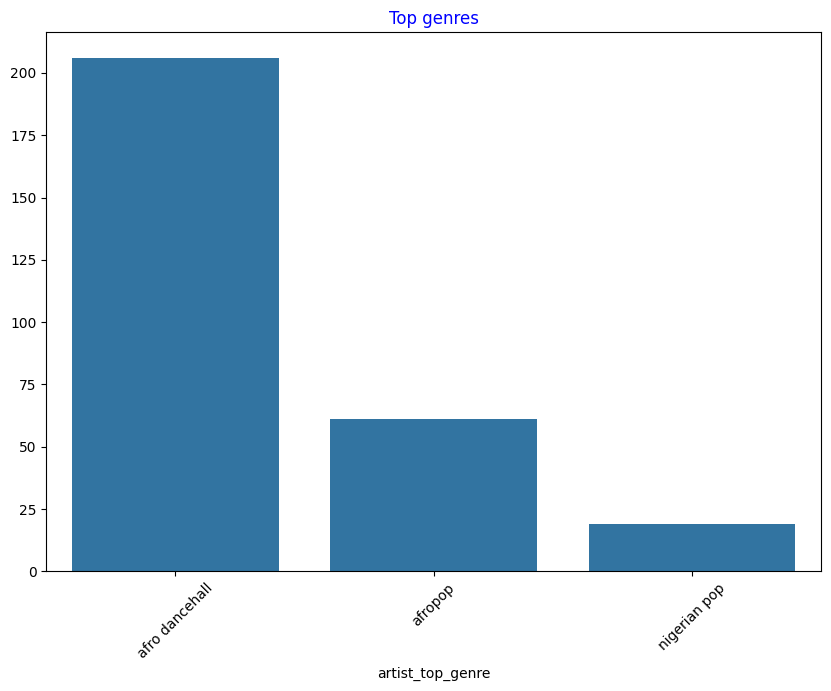

In [138]:
df = df[(df['artist_top_genre'] == 'afro dancehall') | (df['artist_top_genre'] == 'afropop') | (df['artist_top_genre'] == 'nigerian pop')]
df = df[(df['popularity'] > 0)]
top = df['artist_top_genre'].value_counts()
plt.figure(figsize=(10,7))
sns.barplot(x=top.index,y=top.values)
plt.xticks(rotation=45)
plt.title('Top genres',color = 'blue')

<Axes: xlabel='release_date'>

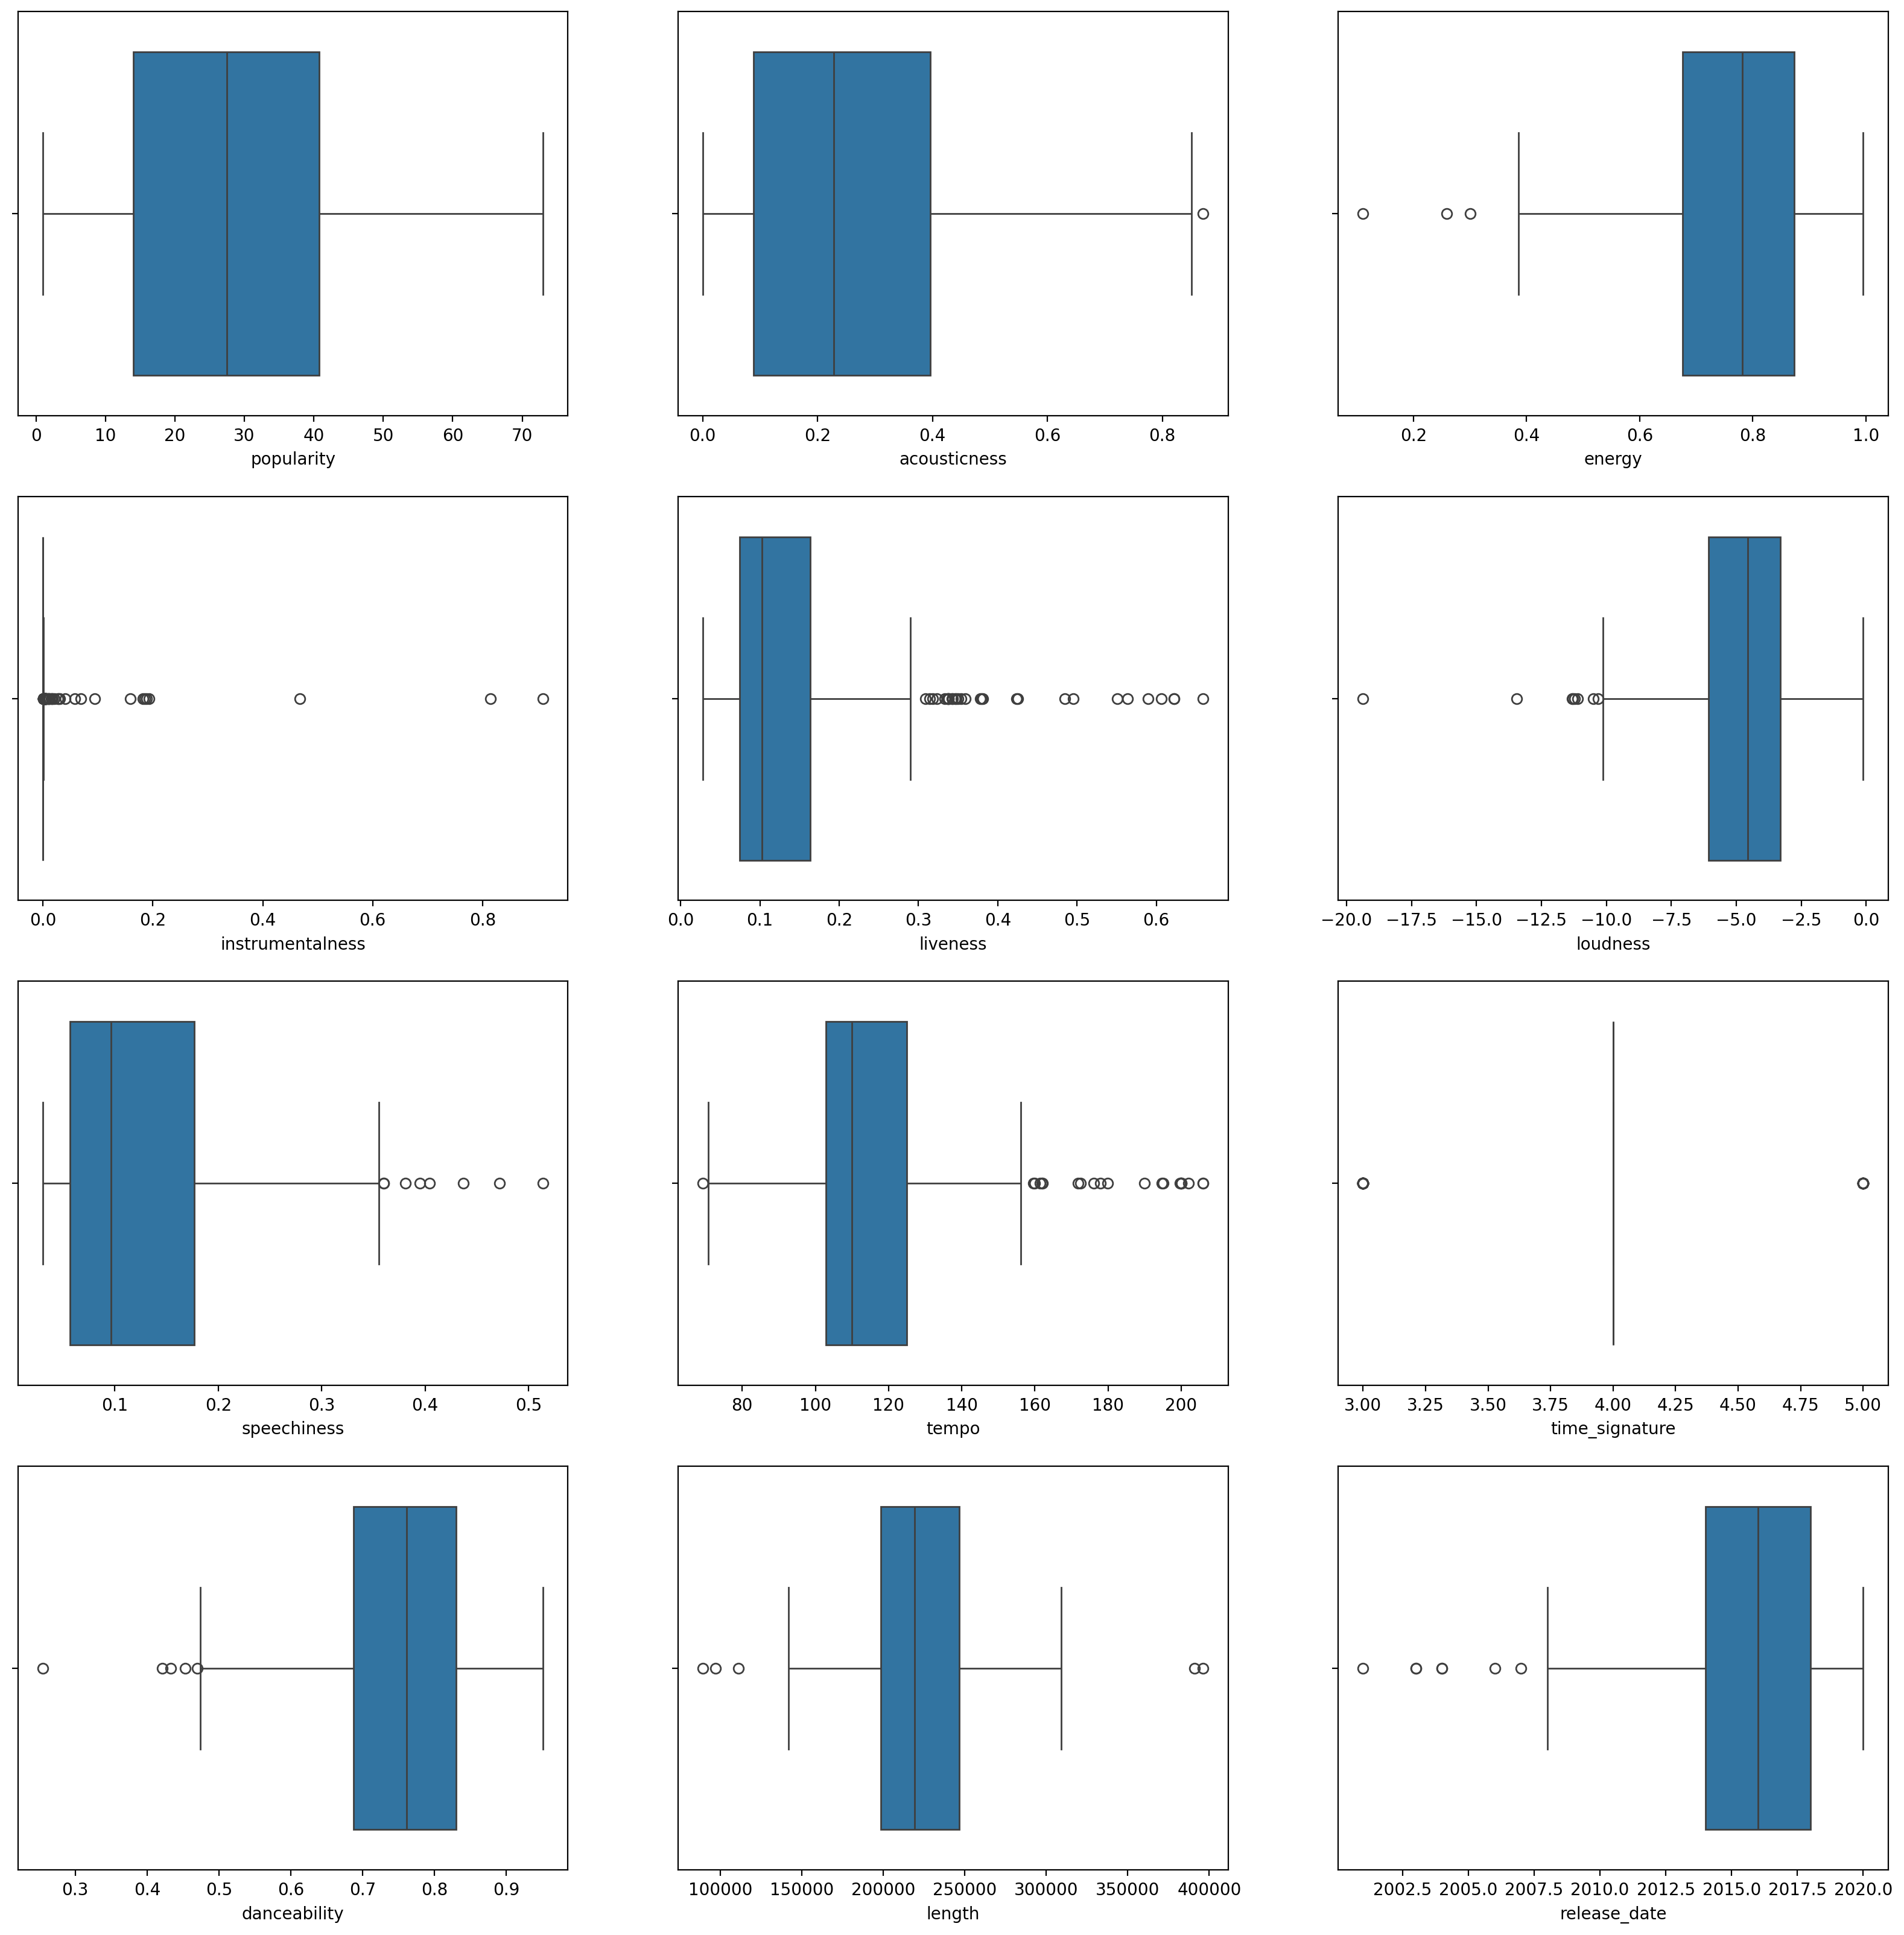

In [139]:
plt.figure(figsize=(20,20), dpi=200)

plt.subplot(4,3,1)
sns.boxplot(x = 'popularity', data = df)

plt.subplot(4,3,2)
sns.boxplot(x = 'acousticness', data = df)

plt.subplot(4,3,3)
sns.boxplot(x = 'energy', data = df)

plt.subplot(4,3,4)
sns.boxplot(x = 'instrumentalness', data = df)

plt.subplot(4,3,5)
sns.boxplot(x = 'liveness', data = df)

plt.subplot(4,3,6)
sns.boxplot(x = 'loudness', data = df)

plt.subplot(4,3,7)
sns.boxplot(x = 'speechiness', data = df)

plt.subplot(4,3,8)
sns.boxplot(x = 'tempo', data = df)

plt.subplot(4,3,9)
sns.boxplot(x = 'time_signature', data = df)

plt.subplot(4,3,10)
sns.boxplot(x = 'danceability', data = df)

plt.subplot(4,3,11)
sns.boxplot(x = 'length', data = df)

plt.subplot(4,3,12)
sns.boxplot(x = 'release_date', data = df)

In [140]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, RobustScaler, StandardScaler
le = LabelEncoder()

scaling_features = ['popularity', 'danceability', 'acousticness', 'loudness', 'energy']
X = df.loc[:, ['artist_top_genre', *scaling_features]]
y = df['artist_top_genre']

X[scaling_features] = MinMaxScaler().fit_transform(X[scaling_features])

X['artist_top_genre'] = le.fit_transform(X['artist_top_genre'])
print(X.head())
y = le.transform(y)

print(y)

   artist_top_genre  popularity  danceability  acousticness  loudness  \
1                 1    0.402778      0.653736      0.093682  0.712979   
3                 2    0.180556      0.918103      0.916124  0.748259   
4                 1    0.333333      0.642241      0.132518  0.691988   
5                 2    0.347222      0.787356      0.145157  0.484672   
6                 2    0.388889      0.808908      0.518576  0.494752   

     energy  
1  0.647059  
3  0.565611  
4  0.816742  
5  0.468326  
6  0.538462  
[1 2 1 2 2 1 2 1 2 2 1 1 2 1 2 1 2 2 1 1 1 0 0 0 0 0 1 0 0 0 0 0 1 2 1 0 0
 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 1 0 0
 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 1 0 0 0 0 0 0 2 0 0 1 0 1 1 0 0 0 0 0 0 0 0
 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 2 1 0 0 0 0 1 0 0 0 0 0 2 1 1 1 0
 1 1 1 0 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 

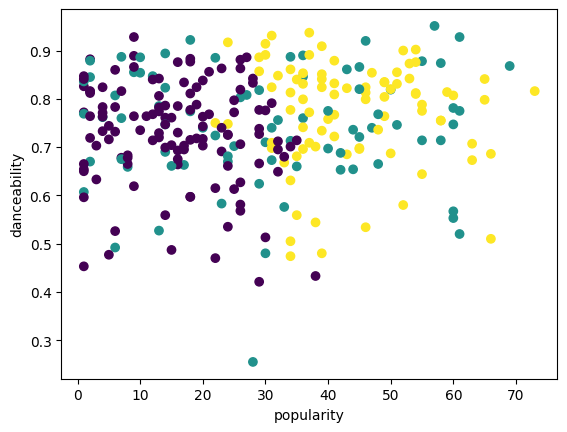

In [141]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
labels = kmeans.predict(X)
plt.scatter(df['popularity'], df['danceability'], c = labels)
plt.xlabel('popularity')
plt.ylabel('danceability')
plt.show()

In [142]:
print(f'Silhouette Score: {silhouette_score(X, labels):.02f}')
correct_labels = sum(y == kmeans.labels_)
print(f'Reesult: {correct_labels} out of {y.size} samples were correctly labeled.')
print(f'Accuracy score: {correct_labels/y.size:.2f}')

Silhouette Score: 0.28
Reesult: 182 out of 286 samples were correctly labeled.
Accuracy score: 0.64
